In [ ]:
!pip install ptflops

Using device: cuda
Train size: 298560
Val size: 53629
Test size: 48870
Relative class weight: 1100.6974169741698
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 121MB/s] 


Model Parameters: 4008829
Model Size (MB): 15.292469024658203
FLOPs: 408.92 MMac


Epoch 1: 100%|██████████| 4665/4665 [52:47<00:00,  1.47it/s]  



Epoch 1/20
Train Loss:     0.9984
Val Accuracy:   0.8347
Val Recall:     0.8947
Val F1:         0.0114
Val AUROC:      0.9290
Val MCC:        0.0638
Val Kappa:      0.0093
→ Saved new best model


...


Epoch 6/20
Train Loss:     0.6200
Val Accuracy:   0.9168
Val Recall:     0.8421
Val F1:         0.0211
Val AUROC:      0.9414
Val MCC:        0.0892
Val Kappa:      0.0190


Epoch 7: 100%|██████████| 4665/4665 [27:49<00:00,  2.79it/s]



Epoch 7/20
Train Loss:     0.6482
Val Accuracy:   0.8620
Val Recall:     0.9123
Val F1:         0.0139
Val AUROC:      0.9457
Val MCC:        0.0730
Val Kappa:      0.0118


Epoch 8: 100%|██████████| 4665/4665 [27:50<00:00,  2.79it/s]



Epoch 8/20
Train Loss:     0.5953
Val Accuracy:   0.9257
Val Recall:     0.8421
Val F1:         0.0235
Val AUROC:      0.9462
Val MCC:        0.0950
Val Kappa:      0.0215
Early stopping triggered


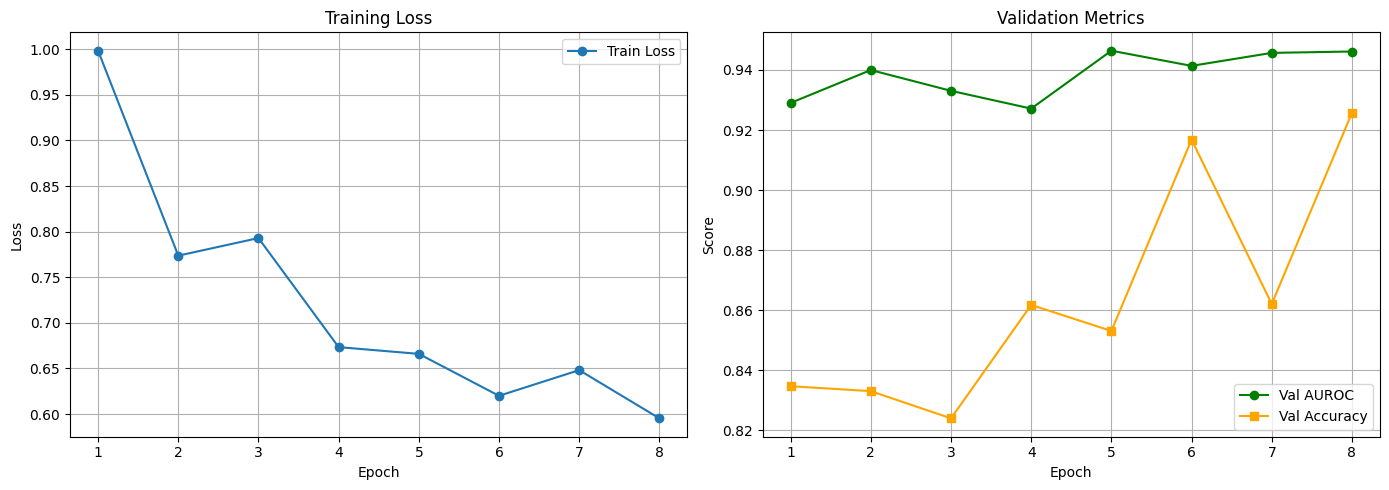


Loading best model for test...

TEST RESULTS
Accuracy:  0.8435
Recall:    0.8308
F1:        0.0139
AUROC:     0.9186
MCC:       0.0675
Kappa:     0.0113
Confusion Matrix:
 [[41167  7638]
 [   11    54]]


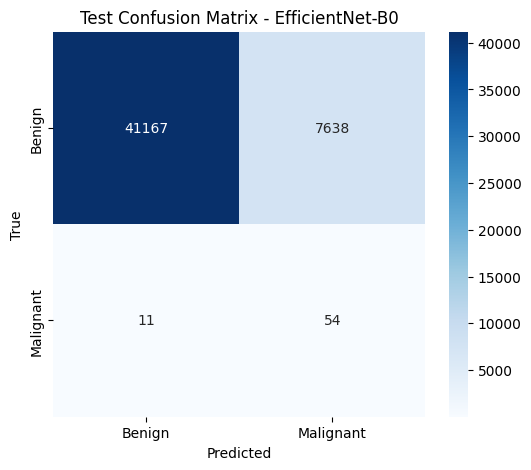

IndexError: index 1 is out of bounds for dimension 1 with size 1

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pandas as pd
import numpy as np
from PIL import Image
import os
import time
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef,
    cohen_kappa_score
)
from ptflops import get_model_complexity_info
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# CONFIG
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIG = {
    "batch_size": 64,
    "epochs": 20,
    "lr": 1e-4,
    "img_size": 224,
    "patience": 3
}
INDEX_PATH = "/kaggle/input/datasets/sanket121234/kagglefinaldataset/final_dataset_index_fixed.csv"
print("Using device:", DEVICE)

# DATASET
class ISICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.base_dir = "/kaggle/input/competitions/isic-2024-challenge/train-image/image"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        filename = os.path.basename(row["path"])
        img_path = os.path.join(self.base_dir, filename)

        assert os.path.exists(img_path), f"Missing image: {img_path}"

        image = np.array(Image.open(img_path).convert("RGB"))

        if self.transform:
            image = self.transform(image=image)["image"]

        label = torch.tensor(row["target"], dtype=torch.float32)
        return image, label

# TRANSFORMS
train_tf = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
    A.Normalize(),
    ToTensorV2()
])

# LOAD DATA
df = pd.read_csv(INDEX_PATH)
train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "val"]
test_df = df[df["split"] == "test"]

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

train_loader = DataLoader(
    ISICDataset(train_df, train_tf),
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=2
)
val_loader = DataLoader(
    ISICDataset(val_df, val_tf),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2
)
test_loader = DataLoader(
    ISICDataset(test_df, val_tf),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=2
)

# CLASS WEIGHT
mal = train_df["target"].sum()
ben = len(train_df) - mal
pos_weight = ben / mal if mal > 0 else 1.0
print("Relative class weight:", pos_weight)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight]).to(DEVICE)
)

# MODEL
model = models.efficientnet_b0(weights="IMAGENET1K_V1")
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])

# MODEL SIZE & FLOPs
params = sum(p.numel() for p in model.parameters())
model_size_mb = params * 4 / (1024**2)
print("Model Parameters:", params)
print("Model Size (MB):", model_size_mb)

macs, _ = get_model_complexity_info(
    model, (3, 224, 224), as_strings=True, print_per_layer_stat=False
)
print("FLOPs:", macs)

# EVALUATION FUNCTION
def evaluate(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            preds = (probs >= 0.5).astype(int)
            y_prob.extend(probs)
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else 0.5
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    return acc, recall, f1, auc, mcc, kappa, cm

# TRAINING CURVES COLLECTION
train_losses = []
val_accs = []
val_aucs = []

# TRAINING LOOP + EARLY STOPPING
best_auc = -float('inf')
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images = images.to(DEVICE)
        labels = labels.unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss_epoch = running_loss / len(train_loader)
    train_losses.append(train_loss_epoch)

    val_acc, val_recall, val_f1, val_auc, val_mcc, val_kappa, val_cm = evaluate(model, val_loader)

    val_accs.append(val_acc)
    val_aucs.append(val_auc)

    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
    print(f"Train Loss:     {train_loss_epoch:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val Recall:     {val_recall:.4f}")
    print(f"Val F1:         {val_f1:.4f}")
    print(f"Val AUROC:      {val_auc:.4f}")
    print(f"Val MCC:        {val_mcc:.4f}")
    print(f"Val Kappa:      {val_kappa:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        counter = 0
        torch.save(model.state_dict(), "best_efficientnet.pth")
        print("→ Saved new best model")
    else:
        counter += 1

    if counter >= CONFIG["patience"]:
        print("Early stopping triggered")
        break

# TRAINING CURVES PLOT
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_aucs, label='Val AUROC', marker='o', color='green')
plt.plot(epochs_range, val_accs, label='Val Accuracy', marker='s', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation Metrics')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves_efficientnet.png', dpi=300)
plt.show()

# TEST EVALUATION + CONFUSION MATRIX HEATMAP
print("\nLoading best model for test...")
model.load_state_dict(torch.load("best_efficientnet.pth"))

test_acc, test_recall, test_f1, test_auc, test_mcc, test_kappa, test_cm = evaluate(model, test_loader)

print("\nTEST RESULTS")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1:        {test_f1:.4f}")
print(f"AUROC:     {test_auc:.4f}")
print(f"MCC:       {test_mcc:.4f}")
print(f"Kappa:     {test_kappa:.4f}")
print("Confusion Matrix:\n", test_cm)

# Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Test Confusion Matrix - EfficientNet-B0')
plt.savefig('test_cm_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# GRAD-CAM IMPLEMENTATION

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def save_activation(module, input, output):
            self.activations = output.detach()

        def save_gradient(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(save_activation)
        target_layer.register_full_backward_hook(save_gradient)

    def generate(self, input_tensor, class_idx=1):
        self.model.eval()
        logit = self.model(input_tensor)

        score = logit[:, class_idx].squeeze()
        self.model.zero_grad()
        score.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=[1, 2], keepdim=True)
        cam = (weights * activations).sum(dim=0, keepdim=True)
        cam = torch.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.squeeze().cpu().numpy()

# GRAD-CAM EXAMPLE (one malignant image)
if not test_df[test_df["target"] == 1].empty:
    idx = test_df[test_df["target"] == 1].index[0]
    row = test_df.loc[idx]
    img_path = row["path"]
    original_img = np.array(Image.open(img_path).convert("RGB"))

    preprocess = A.Compose([
        A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
        A.Normalize(),
        ToTensorV2()
    ])
    input_tensor = preprocess(image=original_img)["image"].unsqueeze(0).to(DEVICE)

    # Target: last conv block in EfficientNet-B0
    target_layer = model.features[-1]

    gradcam = GradCAM(model, target_layer)
    cam = gradcam.generate(input_tensor, class_idx=1)

    cam_resized = cv2.resize(cam, (original_img.shape[1], original_img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    superimposed = (heatmap * 0.4 + original_img * 0.6).astype(np.uint8)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(original_img)
    axs[0].set_title("Original Image")
    axs[1].imshow(cam_resized, cmap='jet')
    axs[1].set_title("Grad-CAM Heatmap")
    axs[2].imshow(superimposed)
    axs[2].set_title("Superimposed (40%)")
    for ax in axs:
        ax.axis('off')
    plt.suptitle(f"Grad-CAM - Malignant Prediction\n{img_path.split('/')[-1]}")
    plt.tight_layout()
    plt.savefig('gradcam_efficientnet_example.png', dpi=300)
    plt.show()
else:
    print("No malignant sample in test set → skipping Grad-CAM demo.")

# INFERENCE TIME
model.eval()
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
start = time.time()
for _ in range(100):
    _ = model(dummy)
end = time.time()
print(f"Average inference time (100 runs): {(end - start)/100:.4f} s")

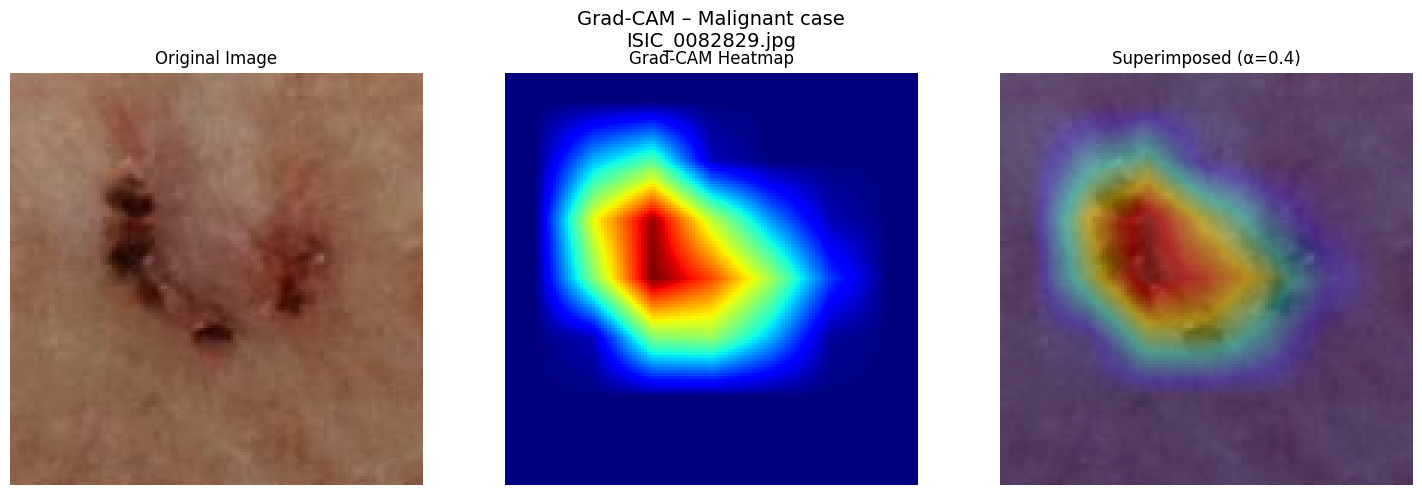

In [ ]:
import torch.nn.functional as F


class GradCAM:

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def save_activation(module, input, output):
            self.activations = output.detach()

        def save_gradient(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(save_activation)
        target_layer.register_full_backward_hook(save_gradient)

    def generate(self, input_tensor, target_class=None):

        self.model.eval()


        logit = self.model(input_tensor)


        score = logit.squeeze(dim=1)


        if target_class == 0:                      # benign
            score = -score

        self.model.zero_grad()
        score.mean().backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = torch.mean(gradients, dim=[1, 2], keepdim=True)

        cam = torch.sum(weights * activations, dim=0, keepdim=True)
        cam = F.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.squeeze().cpu().numpy()



target_layer = model.features[-1]

# target_layer = model.features[-1][0].block[-1][0]

gradcam = GradCAM(model, target_layer)

if not test_df[test_df["target"] == 1].empty:
    idx = test_df[test_df["target"] == 1].index[0]
    row = test_df.loc[idx]
    img_path = row["path"]
    original_img = np.array(Image.open(img_path).convert("RGB"))

    # Preprocess (same as validation)
    preprocess = A.Compose([
        A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    input_tensor = preprocess(image=original_img)["image"].unsqueeze(0).to(DEVICE)

    # Generate CAM for malignant class (positive logit)
    cam = gradcam.generate(input_tensor)           # default = malignant

    # Resize CAM to original image size
    cam_resized = cv2.resize(cam, (original_img.shape[1], original_img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)  # OpenCV → RGB

    alpha = 0.4
    superimposed = (heatmap * alpha + original_img * (1 - alpha)).astype(np.uint8)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(original_img)
    axs[0].set_title("Original Image")
    axs[1].imshow(cam_resized, cmap='jet')
    axs[1].set_title("Grad-CAM Heatmap")
    axs[2].imshow(superimposed)
    axs[2].set_title(f"Superimposed (α={alpha})")
    for ax in axs:
        ax.axis('off')
    plt.suptitle(f"Grad-CAM – Malignant case\n{img_path.split('/')[-1]}", fontsize=14)
    plt.tight_layout()
    plt.savefig("gradcam_efficientnet_malignant.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("No positive (malignant) samples in test set.")

In [ ]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt

class GradCAMPlusPlus:

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        def save_activation(module, input, output):
            self.activations = output.detach()

        def save_gradient(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(save_activation)
        target_layer.register_full_backward_hook(save_gradient)

    def generate(self, input_tensor):

        self.model.eval()

        logit = self.model(input_tensor)

        score = logit.squeeze(dim=1)

        self.model.zero_grad()
        score.mean().backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        alpha_num = torch.relu(gradients)

        alpha_denom = torch.relu(gradients)**2 + 1e-7
        alpha_denom = alpha_denom + torch.relu(gradients)**3 * activations

        weights = alpha_num / (torch.sum(alpha_denom, dim=[1,2], keepdim=True) + 1e-7)
        weights = torch.sum(weights, dim=[1,2], keepdim=True)  # [C, 1, 1]

        cam = torch.sum(weights * activations, dim=0, keepdim=True)  # [1, H, W]
        cam = F.relu(cam)

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.squeeze().cpu().numpy()

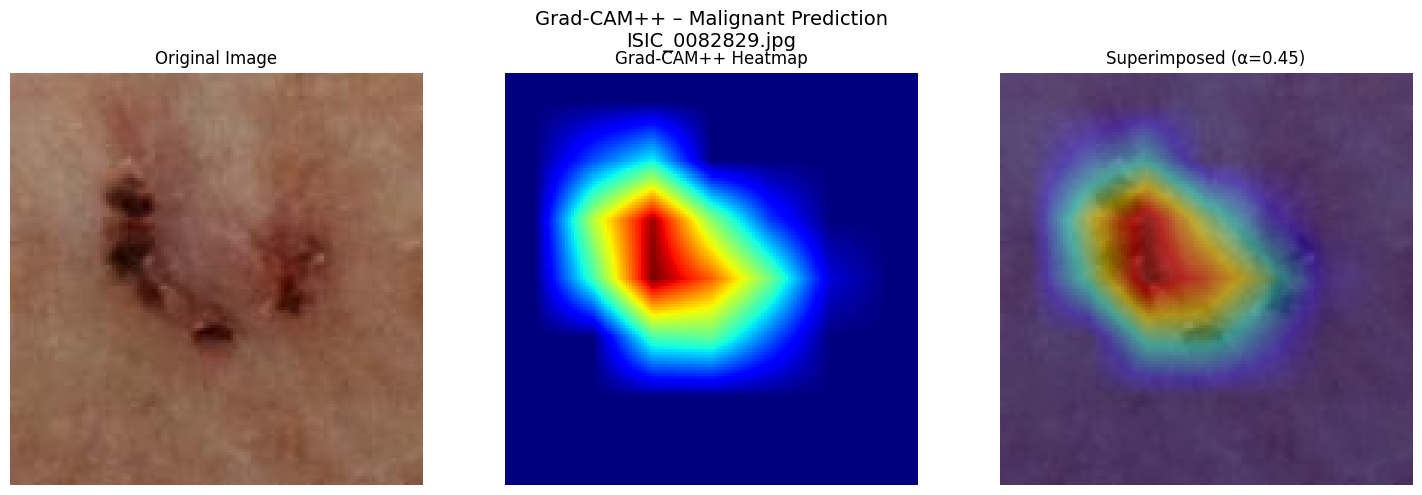

In [ ]:
target_layer = model.features[-1]
# target_layer = model.features[-1][0].block[-1][0]

gradcam_pp = GradCAMPlusPlus(model, target_layer)

#example on one malignant image
if not test_df[test_df["target"] == 1].empty:
    idx = test_df[test_df["target"] == 1].index[0]
    row = test_df.loc[idx]
    img_path = row["path"]
    original_img = np.array(Image.open(img_path).convert("RGB"))

    preprocess = A.Compose([
        A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    input_tensor = preprocess(image=original_img)["image"].unsqueeze(0).to(DEVICE)

    cam = gradcam_pp.generate(input_tensor)

    cam_resized = cv2.resize(cam, (original_img.shape[1], original_img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    alpha = 0.45
    superimposed = (heatmap * alpha + original_img * (1 - alpha)).astype(np.uint8)

    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(original_img)
    axs[0].set_title("Original Image")
    axs[1].imshow(cam_resized, cmap='jet')
    axs[1].set_title("Grad-CAM++ Heatmap")
    axs[2].imshow(superimposed)
    axs[2].set_title(f"Superimposed (α={alpha})")
    for ax in axs:
        ax.axis('off')
    plt.suptitle(f"Grad-CAM++ – Malignant Prediction\n{img_path.split('/')[-1]}", fontsize=14)
    plt.tight_layout()
    plt.savefig("gradcam_plusplus_efficientnet.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("No malignant samples in test set.")

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
from tqdm import tqdm

class ScoreCAM:
s with single logit output
    """
    def __init__(self, model, target_layer, device):
        self.model = model
        self.target_layer = target_layer
        self.device = device
        self.activations = None

        def save_activation(module, input, output):
            self.activations = output.detach()

        target_layer.register_forward_hook(save_activation)

    def generate(self, input_tensor, batch_size=64):
        """
        Args:
            input_tensor:   torch.Tensor [1, 3, 224, 224] normalized, on device
            batch_size:     number of masked images processed per forward pass

        Returns:
            numpy array [H, W] in [0,1]
        """
        self.model.eval()
        assert input_tensor.shape[0] == 1, "Score-CAM expects batch size 1"

        B, C_img, H_img, W_img = input_tensor.shape

        # ── 1. Forward pass to get feature maps ────────────────────────────────
        with torch.no_grad():
            _ = self.model(input_tensor)                # trigger hook
        acts = self.activations                         # [1, C, h, w]

        _, C, feat_h, feat_w = acts.shape

        # Upsample feature maps to input resolution
        acts_up = F.interpolate(acts, size=(H_img, W_img),
                                mode='bilinear', align_corners=False)
        acts_up = acts_up.squeeze(0)                    # [C, H, W]

        # ── 2. Normalize activations per channel to [0,1] ──────────────────────
        flat = acts_up.view(C, -1)
        ch_min = flat.min(dim=1, keepdim=True)[0]       # [C, 1]
        ch_max = flat.max(dim=1, keepdim=True)[0]       # [C, 1]
        ch_min = ch_min.view(C, 1, 1)
        ch_max = ch_max.view(C, 1, 1)

        denom = ch_max - ch_min + 1e-8
        masks_raw = (acts_up - ch_min) / denom          # [C, H, W]

        # ── 3. Create masked inputs ────────────────────────────────────────────
        masks = masks_raw.unsqueeze(1)                  # [C, 1, H, W]
        masked_inputs = input_tensor * masks            # [C, 3, H, W]

        # ── 4. Baseline probability (original image) ───────────────────────────
        with torch.no_grad():
            orig_out = self.model(input_tensor)
            orig_logit = orig_out.squeeze()             # scalar
            orig_prob = torch.sigmoid(orig_logit)

        # ── 5. Forward pass on masked images ───────────────────────────────────
        scores_list = []
        for start in tqdm(range(0, C, batch_size), desc="Score-CAM channels"):
            end = min(start + batch_size, C)
            batch_masked = masked_inputs[start:end]

            with torch.no_grad():
                out = self.model(batch_masked)          # [bs, 1]
                logits = out.squeeze(1)                 # [bs]
                probs = torch.sigmoid(logits)           # [bs]
            scores_list.append(probs)

        channel_scores = torch.cat(scores_list)         # [C]

        # ── 6. Compute weights ─────────────────────────────────────────────────
        weights = torch.relu(channel_scores - orig_prob)
        total = weights.sum()
        if total > 0:
            weights = weights / total
        else:
            # fallback: uniform weights (rare case)
            weights = torch.ones_like(weights) / C

        # ── 7. Weighted sum → CAM ──────────────────────────────────────────────
        cam = torch.sum(weights.view(-1, 1, 1) * masks_raw, dim=0)  # [H, W]
        cam = F.relu(cam)

        # Normalize to [0,1]
        cam_min = cam.min()
        cam_max = cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        else:
            cam = torch.zeros_like(cam)

        return cam.cpu().numpy()

In [ ]:
target_layer = model.features[-1]

# target_layer = model.features[-1][0].block[-1][0]

scorecam = ScoreCAM(model, target_layer, device=DEVICE)

#Malignant example
if not test_df[test_df["target"] == 1].empty:
    idx = test_df[test_df["target"] == 1].index[0]
    row = test_df.loc[idx]
    img_path = row["path"]
    original_img = np.array(Image.open(img_path).convert("RGB"))

    preprocess = A.Compose([
        A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    input_tensor = preprocess(image=original_img)["image"].unsqueeze(0).to(DEVICE)

    # Generate Score-CAM
    cam = scorecam.generate(input_tensor, batch_size=64)   # lower if OOM

    cam_resized = cv2.resize(cam, (original_img.shape[1], original_img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    alpha = 0.45
    superimposed = (heatmap * alpha + original_img * (1 - alpha)).astype(np.uint8)

    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(original_img)
    axs[0].set_title("Original")
    axs[1].imshow(cam_resized, cmap='jet')
    axs[1].set_title("Score-CAM")
    axs[2].imshow(superimposed)
    axs[2].set_title(f"Superimposed (α={alpha})")
    for ax in axs:
        ax.axis('off')
    plt.suptitle(f"Score-CAM – EfficientNet Malignant\n{img_path.split('/')[-1]}")
    plt.tight_layout()
    plt.savefig("scorecam_efficientnet.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    print("No malignant samples in test set.")

NameError: name 'model' is not defined